In [1]:
from copy import deepcopy as cp
from tqdm import tqdm
import numpy as np
import pandas as pd
import codecs
import re

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
from experimental.display import create_tsne_for_plot
from experimental.metrics import bcb_clust

## Загрузка датасета

In [3]:
df = pd.read_pickle("statistics_and_text.pkl")
tlen = [len(elm) for elm in df["textInFile"]]
df["tlen"] = tlen
df = df[df["tlen"] > 100]

df = df[df['textInFile'].str.contains('УДК')]
n_pos_s = list(df['textInFile'].str.find('УДК'))

udk = []
udk2 = []
udk3 = []
udk31 = []
i = 0
for tx in tqdm(df['textInFile']):
    
    end = tx.find("\n", n_pos_s[i]+4)
    # print(tx[n_pos_s[i]+4:end])
    tx2 = tx[n_pos_s[i]+4:end].strip().replace("�", "-").replace("\t", ";").replace(" ", ";").replace(",", ";").replace("+", ";").replace(":", ";").replace("00", "0").replace(".", "")
    tx2 = re.sub("\([\w;.]+\)", "",tx2)
    tx2 = re.sub("[ ]+", " ",tx2)
    tx2 = tx2.replace(" - ", "-").split(";")
    tx2 = [tx_ for tx_ in tx2 if tx_ != "" and any(c.isalpha() for c in tx_) is False and len(tx_) < 25 and "�" not in tx_ and "?" not in tx_]
    #print(tx2)
    udk2_ = []
    udk2_2 = []
    
    for t in tx2:
        try:
            if t[:2] in ['01', '02', '04', '05', '06', '07', '30', '31', '32', '33', '34',
        '35', '36', '37', '50', '51', '52', '53', '54', '55', '57', '61',
        '62', '63', '65', '66', '68']:
                udk2_.append(t[:2])
                udk2_2.append(t[0])
        except:
            continue
    udk.append(np.unique(udk2_).tolist())
    udk3.append("".join(np.unique(udk2_).tolist()))
    udk31.append("".join(np.unique(udk2_2).tolist()))
    # print(udk[-1])
    udk2.append(len(udk[-1]))
    i += 1

df["УДК"] = udk
df["УДК-sp1"] = udk3
df["УДК-sp2"] = udk31
df["УДК-ln"] = udk2
print(len(df["textInFile"]))
df = df[df["УДК-ln"] != 0]
print(len(df["textInFile"]))
good_texts = []

100%|██████████| 4350/4350 [00:00<00:00, 16295.80it/s]

4350
4246


## Предобработка

1. Добавить проверку на то, что перед нами слова русского языка (а не рандомные наборы букв, такое бывает)

In [4]:
all_texts = list(df["textInFile"])
all_udcc = [int(elm[0]) for elm in list(df["УДК-sp2"])]

In [5]:
np.random.seed(0)
selection_ids = np.random.choice(len(all_texts), 500, replace=False, )
all_texts = [all_texts[i] for i in selection_ids]
all_udcc = [all_udcc[i] for i in selection_ids]

In [6]:
## удаление лишних символов, удаление необрабатываемых символов, удаление слишком коротких текстов.

red_texts = []
red_udcc = []
for i in tqdm(range(len(all_texts))):
    rt = all_texts[i].replace('-\n', '')
    rt = rt.replace('\n', ' ')
    rt = re.sub(r'[^а-яё.,:()\[\]0-9А-Я]', ' ', rt)
    # rt = re.sub(r'\s[а-яё.,:()0-9А-Я]\s', ' ', rt)
    rt = rt.replace(' . ', ' ')
    rt = re.sub('\s+', ' ', rt)
    rt = rt.split('.')
    rt = '. '.join([elm.strip() for elm in rt if elm.strip() !=''])
    if(len(rt) > 300):
        if red_texts != [] and red_texts[-1] == rt:
            continue
        red_texts.append(rt)
        red_udcc.append(all_udcc[i])

100%|██████████| 500/500 [00:08<00:00, 61.34it/s]


In [7]:
## Разделение текстов на фрагменты (предложения). Удаление слишком длинных предложений
split_texts = []
for cur_text in tqdm(red_texts):
    split_text = []
    join_next = False
    keywords_rem = False
    cnt = -1
    ps = None
    
    for sent in re.split(r'([а-яё]\. )', cur_text):
        cnt += 1
        if cnt % 2 != 0:
            sent = ps + sent[:-2]
        else:
            ps = cp(sent)
            continue


        # останавливаемся, если дошли до списка литературы
        if re.search('список литературы', sent.lower()) is not None: 
            break
        
        if len(sent) > 1000:
            continue
        if len(sent) < 30:
            continue
        
        # убираем предложения, где слишком много больших букв
        if len(re.findall(r'[А-ЯЁ]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где слишком много цифр
        if len(re.findall(r'[0-9()[]]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где все слова начинаются с большой буквы
        if len(re.findall(r'[А-ЯЁ]', sent)) >= len(sent.split(' ')):
            continue
        # убираем предложение с ключевыми словами (но лишь раз)
        if re.search('ключевые слова', sent.lower()) is not None and not keywords_rem: 
            keywords_rem = True
            continue

        ## убираем последовательности цифр
        sent = re.sub(r'\b(?:[\d.,:()\[\]]\s*){4,}\d\b', '', sent)
        ## убираем последовательности больших букв
        sent = re.sub(r'\b(?:[А-ЯЁ]\s*){4,}\b', '', sent)

        
        if join_next:
            # print("joining")
            split_text[-1] = split_text[-1] + " " + sent
            join_next = False
            continue

        # if len(sent) < 100:
        #     join_next = True
        #     split_text.append(sent)
        #     continue       

        # про несправедливые разбиения
        if (not re.search("рис$",sent.lower()) is None) or (not re.search("табл$",sent.lower()) is None):
            # print("will join")
            join_next = True
            split_text.append(sent)
            continue
        
        # print("adding")
        split_text.append(sent)
    # for i in (split_text):
    #     print(i)
    split_texts.append(split_text)

100%|██████████| 500/500 [00:09<00:00, 51.15it/s]


In [8]:
split_texts[2]

['Аннотация: В рамках анизотропийной теории управления (. ,. ,. ) обращение средней анизотропийной нормы системы в нуль соответствует 2 теории, а обращение в бесконечность При этом естественным образом возникает вопрос, с какого значения анизотропийной нормы ее следует считать близкой к нулю или близкой к бесконечности, а какие значения не близки ни к нулю, ни к бесконечности',
 'В настоящей работе предлагается метод построения нормированной (то есть принимающей значения в единичном интервале) анизотропийной нормы случайного вектора как выбор соответствующего отображения положительной полуоси в единичный интервал',
 'В основополагающей работе [1] введены анизотропийные нормы случайного вектора и линейных систем',
 'Как следствие, были получены многочисленные значимые результаты в соответствующей области теории управления, например [2 11]. Цель исследований [1 11] объединить в рамках единого подхода к теории оптимального управления особенности как 2 , так и методов, основанных на 2 и но

## Сегментация

#### Разделение на сегменты

In [9]:
# segment split model (1).
# В начале сегментируем какой-нибудь существующей моделью (скажем, texttiling)
# На вход идет текст, битый по предложениям, на выходе текст, битый по сегментам.
from experimental.segmentation import simple_segmentation_sentences
from experimental.segmentation import text_tiling_segmentation
from experimental.segmentation import segment_with_graphs

In [10]:
segmented_texts = []
for split_text in tqdm(split_texts):
    segmented_texts.append(simple_segmentation_sentences(split_text))

100%|██████████| 500/500 [00:00<00:00, 250825.50it/s]


##### Нормализация и сохранение нормализованных текстов

In [11]:
from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()

def pymorphy_parse_text(text):
    p_text = []
    for sent in text:
        p_text.append(' '.join([morph.parse(word)[0].normal_form for word in sent.split(' ')]))
    return p_text

In [12]:
# split_texts_normalized = []
# for text in tqdm(split_texts):
#     split_texts_normalized.append(pymorphy_parse_text(text))

In [13]:
from experimental.dset_loadings import create_and_save_dataframe
from experimental.dset_loadings import load_and_parse_dataframe

In [14]:
# create_and_save_dataframe(split_texts, split_texts_normalized, all_udcc)
split_texts, split_texts_normalized, all_udcc = load_and_parse_dataframe()

In [15]:
# segmented_texts = []
# for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
#     segmented_texts.append(text_tiling_segmentation(split_text, split_text_normalized))

segmented_texts = []
for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
    if len(split_text) > 0:
        segmented_texts.append(segment_with_graphs(split_text, split_text_normalized))
    else:
        segmented_texts.append([])

 64%|██████▍   | 320/500 [08:01<03:38,  1.22s/it]  c:\Users\max\Desktop\semantic_similarity\experimental\graph_segmentation\main.py:140: RuntimeWarning: Mean of empty slice.
  threshold = depth_scores.mean()-depth_scores.std()
C:\Users\max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide

#### Классификация сегментов

In [16]:
from similarity_module.similarity_measure.paper_similarity import get_sentence_embedding
from similarity_module.similarity_measure.paper_similarity import calculate_text_similarities
from similarity_module.segmentation_models.paper_segmentation_model import text_segment_classifier

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [17]:
# segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_0.74_.wt", only_cpu= True)
segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_d2_0.5.wt", only_cpu= True)
LabtoNum = {'None' : 0 , 'Resl' : 1, 'Obl' : 2, 'Goal' : 3, 'Algo' : 4}
NumToLab = { 0 : 'None', 1 : 'Resl', 2 : 'Obl', 3 : 'Goal', 4 : 'Algo'}
segment_model.pipeline.model.config.id2label = NumToLab
segment_model.pipeline.model.config.label2id = LabtoNum


loading base model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


reconfiguring classifier head...
loading new weights...
done!


In [18]:
print(segment_model.pipeline.model.config.id2label)
print(segment_model.pipeline.model.config.label2id)

{0: 'None', 1: 'Resl', 2: 'Obl', 3: 'Goal', 4: 'Algo'}
{'None': 0, 'Resl': 1, 'Obl': 2, 'Goal': 3, 'Algo': 4}


In [19]:
# all_text_segmented = []
# i = 0
# for text in tqdm(segmented_texts):
#     i += 1 
#     text_dict = {}
#     if len(text) != 0:
#         preds = segment_model.mass_predict(text, verbal = False)
#         # print(preds)
#         # break
#         for i in range(len(preds)):
#             text_dict.setdefault(preds[i],[])
#             text_dict[preds[i]].append(text[i])
#         # for tag in text_dict:
#         #     print(len(text_dict[tag]))
#         # print()
#     all_text_segmented.append(text_dict)

In [20]:
# # это вариант для двухклассового разбиения на "правильный текст" и "неправильный текст"
# all_text_segmented = []
# i = 0
# for text in tqdm(segmented_texts):
#     i += 1 
#     text_dict = {}
#     if len(text) != 0:
#         preds = segment_model.mass_predict(text, verbal = False)
#         # print(preds)
#         # break
#         for i in range(len(preds)):
#             if preds[i] == 'None':
#                 text_dict.setdefault(preds[i],[])
#                 text_dict[preds[i]].append(text[i])
#             else:
#                 text_dict.setdefault('Algo',[])
#                 text_dict['Algo'].append(text[i])
#         # for tag in text_dict:
#         #     print(len(text_dict[tag]))
#         # print()
#     # print([[k, len(text_dict[k])] for k in text_dict.keys()])
#     all_text_segmented.append(text_dict)

In [21]:
all_text_segmented = []
i = 0
for text in tqdm(segmented_texts):
    i += 1 
    text_dict = {}
    if len(text) != 0:
        text_dict = segment_model.mass_predict_alter(text, verbal = False, n_samples = 5, unique = True)
        # # print(preds)
        # # break
        # for i in range(len(preds)):
        #     text_dict.setdefault(preds[i],[])
        #     text_dict[preds[i]].append(text[i])
        # # for tag in text_dict:
        # #     print(len(text_dict[tag]))
        # # print()
    all_text_segmented.append(text_dict)

100%|██████████| 500/500 [09:44<00:00,  1.17s/it]  


In [22]:
wk = all_text_segmented[4]
for key in wk.keys():
    if key != "None":
        print(key)
        for elm in wk[key]:
            print(elm)

Resl
 гидрометаллургическая и пирометаллургическая переработка являются достаточно эффективными с экономической точки зрения1 [12], однако отсутствие системы сбора и транспортировки электронных отходов к месту переработки ставит под вопрос экономическую целесообразность всего процесса . Согласно имеющимся данным о коммерческой составляющей процесса переработки, минимальные производственные мощности должны быть обеспечены объемом электронного лома в объеме 500 кг в день (или  т в год)2. В отличие от традиционных источников лома, которые локализованы в местах потребления металлсодержащей продукции (таких как промышленные предприятия, здания и сооружения), электронные отходы относительно равномерно (с учетом различий в уровне дохода) распределены по всей территории проживания населения [12]. В регионах, где плотность населения является низкой, формирование эффективной системы сбора и транспортировки электронных отходов (ЭО) может быть проблематичным, и, как следствие, отсутствие такой сис

## Векторизация

In [23]:
available_tags = list(segment_model.pipeline.model.config.label2id.keys())

In [24]:
all_text_vectorized = []
for text in tqdm(all_text_segmented):
    elm_dict = {tag : None for tag in available_tags}
    for tag in text:
        elm_dict[tag] = np.array([get_sentence_embedding(sent) for sent in text[tag]])
    all_text_vectorized.append(elm_dict)

100%|██████████| 500/500 [10:46<00:00,  1.29s/it]


## Измерение близости

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
def ot_text_sim_func(lhs_vectors, rhs_vectors):
    return cosine_similarity(lhs_vectors, rhs_vectors)

In [ ]:
for i in range(len(all_text_vectorized)):
    torm = []
    for elm in all_text_vectorized[i]:
        if all_text_vectorized[i][elm] == []:
            torm.append(elm)
    for elm in torm:
        all_text_vectorized[i].pop(elm)

C:\Users\max\AppData\Local\Temp\ipykernel_17600\1957365614.py:4: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  if all_text_vectorized[i][elm] == []:
C:\Users\max\AppData\Local\Temp\ipykernel_17600\1957365614.py:4: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if all_text_vectorized[i][elm] == []:


In [ ]:
text_similarities_matrix = np.zeros((len(all_text_vectorized), len(all_text_vectorized), len(available_tags[:])))
for i in tqdm(range(len(all_text_vectorized))):
    for j in range(i, len(all_text_vectorized)):
        t_sims = calculate_text_similariWties(all_text_vectorized[i], all_text_vectorized[j], compare_sentences = True, selection_method = 5, comparation_method=ot_text_sim_func)
        text_similarities_matrix[i][j] = np.array(list(t_sims.values())[:])
## заполняем вторую половину матрицы
for i in range(len(text_similarities_matrix)):
    for j in range(0,i):
        text_similarities_matrix[i,j] = text_similarities_matrix[j,i]

  0%|          | 0/500 [00:00<?, ?it/s]


ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
available_tags

['None', 'Resl', 'Obl', 'Goal', 'Algo']

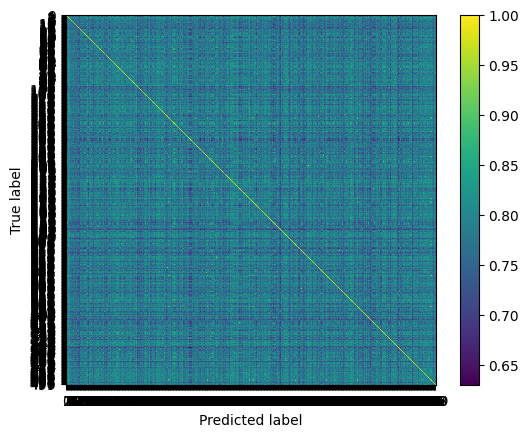

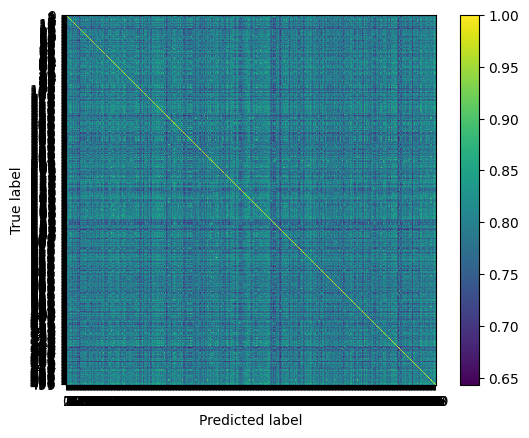

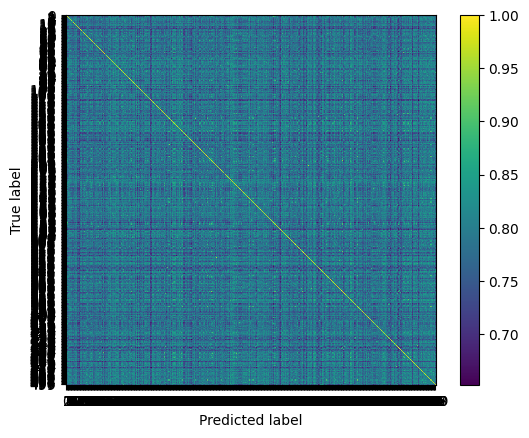

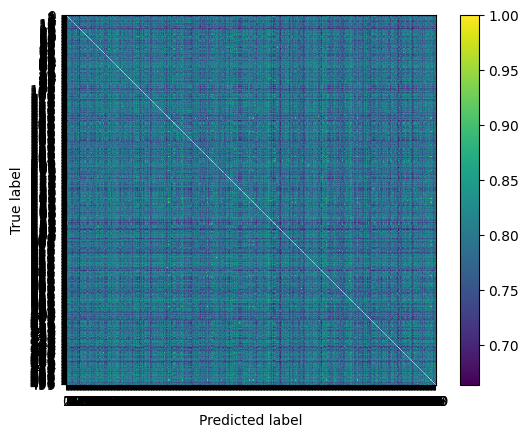

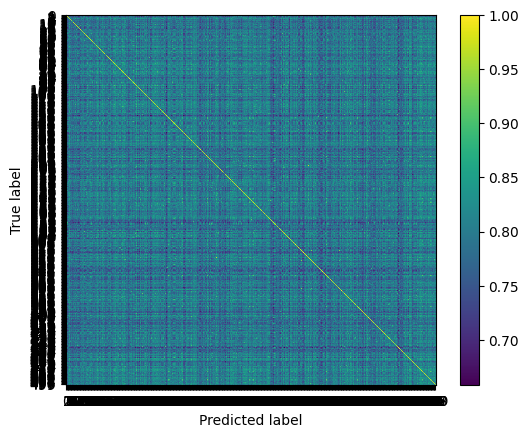

In [ ]:
import pylab

disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,0], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,1], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,2], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,3], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,4], display_labels = None)
disp.plot(include_values = False)
pylab.show()

In [ ]:
text_similarities_matrix = np.nan_to_num(text_similarities_matrix, nan = 1e-3)

## Кластеризация (?)

In [ ]:
true_clusters = red_udcc

In [ ]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,0])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,1])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,2])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,3])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,4])
print(bcb_clust(clustering.labels_, true_clusters))

(0.4198425413124487, 0.4299651944359837, 0.4097918269205088)
(0.4097318768869225, 0.40696914567869696, 0.40299275924371414)
(0.3949169599134814, 0.39831020621917373, 0.39317365852477537)
(0.41159210557859743, 0.41424936541780716, 0.40672815119979816)
(0.39681962281163485, 0.3872652270334686, 0.3902365101639451)


In [ ]:
import random
import numpy as np

def random_segmentation(true_seg):
    claster_count = len(np.unique(true_seg))
    random_clasters = []
    for _ in true_seg:
        random_clasters.append(random.choice(range(claster_count)))
    return random_clasters

bcb_clust(random_segmentation(true_clusters), true_clusters)

(0.259503063954554, 0.2568792899092084, 0.2567355769832126)

## Оценка